In [33]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    
from fizinfo import *

In [34]:
# Az órai anyagban tanult "pattogós labda modell" segítségével modellezze egy kosárlabda mozgását az alábbi paraméterekkel: A labdát vegyük 75 cm kerületűnek, 580 g tömegűnek; a pattogáskor vett $D$ érték legyen 3500 N/m, a pattanáskori fékeződési erő pedig 2 N.
# 
# a) A labdát először 1,8 m magasról, a vízszintessel 55 fokos szöget bezáróan, 10 m/s sebességgel indítjuk. Rajzolja fel a labda pályáját az első 30 másodpercben, feltéve, hogy nem ütközik semminek!
# 
# b) Mikor, az eldobás helyétől milyen távol és milyen sebességgel éri el a talajt először a labda?
# 
# c) Ha tőlünk 3 m-re áll valaki, aki ugrással együtt 2,6 m magasra tudja nyújtani a kezét, akkor átrepül-e felette a labda?
# 
# d) Feltéve, hogy a labda egy nagy pályán szabadon pattoghat, keresse meg a pálya első 10 felső holtpontját. Egy kis táblázatban adja meg ezek magasságát és az itt mérhető sebesség nagyságát!
# 
# e) Készítsen ábrát, melyen a labda pályája szürkével, az előző pontban megtalált felső holtpontok pedig kékkel vannak jelölve!
# 
# f) Ha csupán az eldobás szögét változtathatjuk, akkor milyen szög esetén lesz maximális az ötödik lepattanás távolsága az eldobás helyétől mérve és mekkora ez a távolság?

In [35]:
def create_grav_közeg_talaj_F_m(m, C, A, rho, D, F_f, g=9.81):
    """
    Visszaadja egy labda erő- és tömegfüggvényét gravitáció,
    közegellenállás és rugalmas talajtól való visszapattanás figyelembevételével.

    Paraméterek:
        m    : labda tömege [kg]
        C    : közegellenállási együttható (C_D)
        A    : labda homlokfelülete [m²]
        rho  : közeg sűrűsége [kg/m³]
        D    : rugalmas talajmodell merevségi együtthatója [N/m]
              (talaj-reakcióerő: F_talaj = D * behatolás, ha y <= 0)
        F_f  : súrlódási erő nagysága a talajon [N]
              (vízszintes irányban lassít, ha a labda érinti a talajt)
        g    : gravitációs gyorsulás [m/s²]
    """

    def tomeg_fuggveny(t):
        # A labda tömege állandó (nincs tömegváltozás)
        return m

    def ero_fuggveny(t, helyzet, sebesseg, tomeg):
        """
        Az összes erő eredője [N], 2D vektorként (x, y).

        Hatások:
          - gravitáció         : lefelé (y irány)
          - közegellenállás    : sebességgel ellentétes, v²-tel arányos
          - talaj reakcióerő   : felfelé, ha y <= 0 (rugalmas behatolás)
          - talaj súrlódás     : vízszintes irányban, ha y <= 0
        """

        eredo_ero = np.array([0.0, 0.0], dtype=np.float64)

        # --- Gravitációs erő ---
        eredo_ero[1] -= tomeg * g                                  # F_g = -m·g (y irányban lefelé)

        # --- Közegellenállási erő ---
        sebesseg_nagysag = np.sqrt((sebesseg ** 2).sum())          # |v| [m/s]
        if sebesseg_nagysag > 1e-10:
            eredo_ero -= 0.5 * C * A * rho \
                         * sebesseg * sebesseg_nagysag             # F_drag = ½·C·A·ρ·v·|v|, iránya: -v̂

        # --- Talaj reakcióerő (rugalmas ütközésmodell) ---
        y = helyzet[1]
        vy = sebesseg[1]
        if y <= 0.0:                                               # labda elérte / átment a talajon
            behatolas = -y                                         # behatolás mélysége [m] (pozitív)
            eredo_ero[1] += D * behatolas                         # F_talaj = D · δ (felfelé)

            # Talaj súrlódás: csak ha a labda érinti a talajt és mozog vízszintesen
            vx = sebesseg[0]
            if abs(vx) > 1e-10:
                eredo_ero[0] -= F_f * np.sign(vx)                 # F_súrl = -F_f · sign(vx)

        return eredo_ero

    return ero_fuggveny, tomeg_fuggveny

# --- Labda fizikai paraméterei ---
m_basketball = 0.58          # labda tömege [kg]
perim_ball   = 0.75          # labda kerülete [m]

r   = perim_ball / (2 * np.pi)   # labda sugara [m]
A   = np.pi * r**2               # homlokfelület (keresztmetszet) [m²]
C   = 0.47                       # közegellenállási együttható (gömb)
rho = 1.3                        # levegő sűrűsége [kg/m³]
g   = 9.81                       # gravitációs gyorsulás [m/s²]

# --- Talajmodell paraméterei ---
D   = 3500.0   # rugalmas talaj merevségi együtthatója [N/m]
F_f = 2.0      # talaj súrlódási erő [N]

# --- Erő- és tömegfüggvény példányosítása ---
F_ball, m_ball = create_grav_közeg_talaj_F_m(m_basketball, C, A, rho, D, F_f, g)

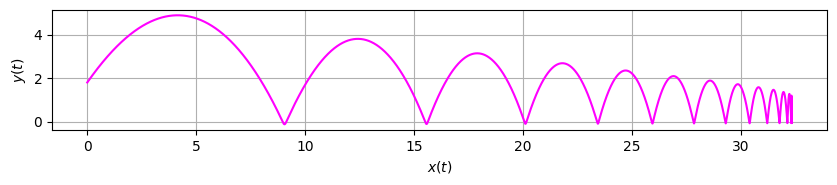

In [36]:
# ============================================================
# a) Pályagörbe – 1,8 m magasról, 55°, 10 m/s, 30 másodperc
#    (nem ütközik semminek → talajmodell nem aktiválódik,
#     csak gravitáció + közegellenállás hat)
# ============================================================

# --- Kezdőfeltételek ---
x0        = 0.0    # kezdeti x pozíció [m]
y0        = 1.8    # kezdeti y pozíció [m]
v0        = 10.0   # kezdeti sebesség nagysága [m/s]
alpha_deg = 55.0   # indulási szög (vízszintestől) [°]

v0_x = v0 * np.cos(np.radians(alpha_deg))   # vízszintes sebesség-komponens [m/s]
v0_y = v0 * np.sin(np.radians(alpha_deg))   # függőleges sebesség-komponens [m/s]

# --- Numerikus dinamikai számítás ---
ball_din = num_dinam(2)                      # 2D mozgás
ball_din.set_time_range(0.0, 30.0, 0.001)   # t ∈ [0, 30] s, dt = 0.001 s
ball_din.set_mass_fun(m_ball)               # tömegfüggvény (állandó)
ball_din.set_F_fun(F_ball)                  # erőfüggvény
ball_din.set_r0_v0([x0, y0], [v0_x, v0_y]) # kezdeti hely és sebesség

ball_din.full_dinam_calc()                  # numerikus integráció futtatása

# --- Pályagörbe kirajzolása ---
ball_din.plot_rcomp()                       # x(t) és y(t) komponensek külön-külön

In [57]:
# b) Mikor, az eldobás helyétől milyen távol és milyen sebességgel éri el a talajt először a labda?

# --- Az első földetérés indexének meghatározása ---
# arg_eq megkeresi az összes időlépést, ahol y ≈ 0 (talajszint)
# [0] választja ki ezek közül a legkorábbit → első földetérés
ind_ground       = arg_eq(ball_din.r[:, 1], 0.0)   # összes talajszint-átlépés indexei
ind_ground_first = ind_ground[0]                    # első földetérés indexe

# --- Segédváltozók az olvashatóságért ---
vabs   = vect_abs(ball_din.v)   # sebességvektor abszolút értéke minden időlépésben [m/s]
x_work = ball_din.r[:, 0]       # x koordináta idősor [m]
y_work = ball_din.r[:, 1]       # y koordináta idősor [m]

# --- Eredmények kiírása az első földetérés pillanatában ---
print(f"Első földetérés:")
print(f"  t   = {ball_din.t[ind_ground_first]:.2f} s   (eltelt idő az indítástól)")
print(f"  x   = {x_work[ind_ground_first]:.2f} m   (vízszintes távolság az eldobás helyétől)")
print(f" |v|  = {vabs[ind_ground_first]:.2f} m/s (becsapódási sebesség nagysága)")

Első földetérés:
  t   = 1.80 s   (eltelt idő az indítástól)
  x   = 8.97 m   (vízszintes távolság az eldobás helyétől)
 |v|  = 10.09 m/s (becsapódási sebesség nagysága)


In [41]:
# c) Ha tőlünk 3 m-re áll valaki, aki ugrással együtt 2,6 m magasra tudja nyújtani a kezét, akkor átrepül-e felette a labda?


# Tőlünk 3 m-re álló másik játékos: x=3-nál van.
# Labda mit csinál a másik játékosnál? Első lépés: mely indexnél lesz x=3?
ind_x3 = arg_eq(x_work, 3.0)[0]  
# a végére a [0] kell, hogy ne tömb, hanem egyetlen float legyen; nem fordul vissza, úgyis csak 1 megoldás van

# az előző indexnél ez az y koordináta, azaz a test magassága
y_x3 = y_work[ind_x3]
print(f"A labda x=3 m-nél {y_x3:.2f} m magasan jár.")  
# Ezt nem kérték kiírni, de érdemes. 

# programozzuk be a döntést:
if (y_x3 > 2.6):
    print("Átmegy a védő felett.")
else:
    print("Nem megy át a védő felett.")
    
# A teljes ponthoz kell ez az if, nem elég saját aggyal eldönteni, átmegy-e a védő felett.

A labda x=3 m-nél 4.63 m magasan jár.
Átmegy a védő felett.


In [42]:
# d)

In [43]:
# Magasság szerinti holtpont: v_y=0; függőleges irányban 0 a pill. seb.
ind_holtpont = arg_eq(ball_din.v[:, 1], 0)

# Vigyázz! Vannak alsó holtpontok is, amikor a labda elindul felfelé. Ezeket ki kell zárni.

# Felső holtpont: olyan holtpont, ahol a_y<0, azaz lefelé mutat a gyorsulás.
# Magyarázat: a talajon pattanva felfelé gyorsul a test, azaz az alsó holtpontokban a_y>0
ind_felsoholtpont = ind_holtpont[ball_din.a[ind_holtpont,1]<0] # válogatunk a holtpontok közt

# Válaszzuk ki az első 10 felső holtpontot:
ind_felsoholtpont10 = ind_felsoholtpont[:10]
print(ind_felsoholtpont10)  # debug célú print, érdemes, de nem közelező

[  777  2706  4432  6016  7491  8878 10193 11448 12649 13805]


In [44]:
# Most már csak ki kell írni:
print("Az első 10 felső holtpont adatai:\n")

print("y [m]\t|v| [m/s]")
for ind in ind_felsoholtpont10:
    print(f"{y_work[ind]:.2f}\t{vabs[ind]:.2f}")

Az első 10 felső holtpont adatai:

y [m]	|v| [m/s]
4.89	5.05
3.80	3.62
3.14	2.77
2.68	2.19
2.35	1.76
2.09	1.42
1.89	1.14
1.72	0.90
1.58	0.69
1.46	0.50


In [45]:
# e)

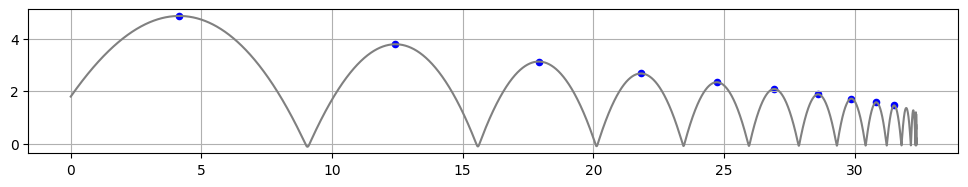

In [46]:
# másolva pl. numpy-bool-array.ipynb-ből, majd átírva a változókat

fig=plt.figure(figsize=(12,5))  
ax1=plt.subplot(111)

ax1.plot(x_work, y_work, color="grey")  # a pályagörbe
ax1.scatter(x_work[ind_felsoholtpont10], y_work[ind_felsoholtpont10], color="blue", s=20)    # a holtpontok
ax1.set_aspect(aspect='equal')
ax1.grid()

Ha itt nem jó helyen lennének a holtpontok, akkor az előző pontra vissza kellene térni, javítani.

In [47]:
# f)

In [48]:
# Egy def alá a teljes szimulációt összemásoljuk, alpha_deg-et kiemelve.

def otodiklepatt(alpha_deg):
    x0=0.0
    y0=1.8
    v0=10.0
    v0_x=v0*np.cos(np.radians(alpha_deg))
    v0_y=v0*np.sin(np.radians(alpha_deg))


    # dinamikai számítások
    ball_din=num_dinam(2)
    ball_din.set_time_range(0.0, 30.0, 0.001)
    ball_din.set_mass_fun(m_ball)
    ball_din.set_F_fun(F_ball)   
    ball_din.set_r0_v0([x0, y0], [v0_x, v0_y])

    ball_din.full_dinam_calc()
    y_work=ball_din.r[:,1]
    
    # végeredmény: 5. lepattanás
    # talaj érés indexei:
    ind_ground = arg_eq(y_work, 0.0)
    
    # 5. talajérés 
    ind_ground_5 = ind_ground[8]
    # Miért a "8"-as index? Mert egy lepattanáskor lefele és felfele is lesz y=0, rövid idővel egymás után.
    # Lásd a pattogó labda modell magyarázata gyakorlaton.
    # Ezért a 0-s elem az első földetérés, az 1-es az első felpatanás, 
    # a 2-es elem a második földetérés, a 3-as a második felpattanás, ...
    
    # Lehetne máshogy is okoskodni, de nekem ez jutott eszembe.
    
    return ball_din.r[ind_ground_5, 0]

In [49]:
otodiklepatt(55.0)
# ellenőrzési lehetőség: 55 foknál az a) pontbeli grafikonnal összevethetjük az értéket

np.float64(25.91789536588426)

In [50]:
# üres listák az eredmény gyűjtéséhez
x5_list=[]
alpha_deg_list=[]

# Ciklus a lehetséges tartományon:
for alpha_deg in np.arange(0.0, 90.0, 1.0):
    x5 = otodiklepatt(alpha_deg)
    
    # eredmény eltárolása a listákban:
    x5_list.append(x5)
    alpha_deg_list.append(alpha_deg)

In [51]:
# Debug célból ki lehet próbálni:
#print(alpha_deg_list)
#print(x5_list)

In [52]:
# max elem indexének meghatározása: a listát np.array()-jal tömbbé alakítjuk és ebben keresünk argmax()-szal.
ind_x5_max = np.array(x5_list).argmax()
alpha_x5_max = alpha_deg_list[ind_x5_max]

# Eredmény printelése:
print(f"Az 5. lepattanás alpha={alpha_x5_max}° esetén lesz a legtávolabb.")
print(f"Ez a távolság: x={x5_list[ind_x5_max]:.2f} m.")

Az 5. lepattanás alpha=27.0° esetén lesz a legtávolabb.
Ez a távolság: x=32.86 m.
